# intelligent-book-discovery-engine 
In this notebook, we build a intelligent-book-discovery-engine using the Book-Crossing dataset.
The process is divided into:
1. Data Loading & Cleaning
2. Exploratory Data Analysis (EDA)
3. Popularity-Based Recommender System
4. Item-Based Collaborative Filtering Recommender

## Import Libraries & Load Data

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
books = pd.read_csv("Books.csv", encoding="latin-1", low_memory=False)
ratings = pd.read_csv("Ratings.csv", encoding="latin-1", low_memory=False)
users = pd.read_csv("Users.csv", encoding="latin-1", low_memory=False)

print(f"Books: {books.shape}, Ratings: {ratings.shape}, Users: {users.shape}")

Books: (271360, 8), Ratings: (1149780, 3), Users: (278858, 3)


In [63]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [64]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [65]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [66]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [67]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [68]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [69]:
ratings.isnull().sum()


User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [70]:
books.duplicated().sum()

np.int64(0)

In [71]:
ratings.duplicated().sum()


np.int64(0)

In [72]:
users.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)
EDA is performed before building the recommender system to understand the structure, quality, and important patterns in the Books, Users, and Ratings datasets.

## Import libraries for EDA
We use Matplotlib and Seaborn for visualization. Pandas is already imported above and is used for data inspection and analysis.

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## Understand the datasets
First, we check the number of rows and columns and display the column names. This tells us what information is available in each dataset.

In [74]:
print('Books Dataset:')
print('Shape:', books.shape)
print('Columns:', books.columns.tolist())

print('\nUsers Dataset:')
print('Shape:', users.shape)
print('Columns:', users.columns.tolist())

print('\nRatings Dataset:')
print('Shape:', ratings.shape)
print('Columns:', ratings.columns.tolist())

Books Dataset:
Shape: (271360, 8)
Columns: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']

Users Dataset:
Shape: (278858, 3)
Columns: ['User-ID', 'Location', 'Age']

Ratings Dataset:
Shape: (1149780, 3)
Columns: ['User-ID', 'ISBN', 'Book-Rating']


## Check data types and basic information
info() shows the data types and non-null counts. This helps identify columns that may need cleaning or type conversion.

In [75]:
print('--- Books Information ---')
books.info()

print('\n--- Users Information ---')
users.info()

print('\n--- Ratings Information ---')
ratings.info()

--- Books Information ---
<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ISBN                 271360 non-null  str  
 1   Book-Title           271360 non-null  str  
 2   Book-Author          271358 non-null  str  
 3   Year-Of-Publication  271360 non-null  str  
 4   Publisher            271358 non-null  str  
 5   Image-URL-S          271360 non-null  str  
 6   Image-URL-M          271360 non-null  str  
 7   Image-URL-L          271357 non-null  str  
dtypes: str(8)
memory usage: 84.5 MB

--- Users Information ---
<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), in

## Statistical summary
For numerical columns, describe() gives statistics such as count, mean, standard deviation, minimum, maximum, and quartiles. This is especially useful for Age and Book-Rating.

In [76]:
print('--- Users Numerical Summary ---')
display(users.describe(include='all'))

print('--- Ratings Numerical Summary ---')
display(ratings.describe(include='all'))

--- Users Numerical Summary ---


,User-ID,Location,Age
count,278858.00000,278858,168096.000000
unique,NaN,57339,NaN
top,NaN,"london, england, united kingdom",NaN
freq,NaN,2506,NaN
mean,139429.50000,NaN,34.751434
std,80499.51502,NaN,14.428097
min,1.00000,NaN,0.000000
25%,69715.25000,NaN,24.000000
50%,139429.50000,NaN,32.000000
75%,209143.75000,NaN,44.000000


--- Ratings Numerical Summary ---


,User-ID,ISBN,Book-Rating
count,1.149780e+06,1149780,1.149780e+06
unique,NaN,340556,NaN
top,NaN,0971880107,NaN
freq,NaN,2502,NaN
mean,1.403864e+05,NaN,2.866950e+00
std,8.056228e+04,NaN,3.854184e+00
min,2.000000e+00,NaN,0.000000e+00
25%,7.034500e+04,NaN,0.000000e+00
50%,1.410100e+05,NaN,0.000000e+00
75%,2.110280e+05,NaN,7.000000e+00


## Missing-value analysis
We check how many missing values are present in every column. Missing values are important because they can affect analysis and later recommendation steps.

In [77]:
missing_summary = pd.DataFrame({
    'Books Missing': books.isnull().sum(),
    'Users Missing': users.isnull().sum(),
    'Ratings Missing': ratings.isnull().sum()
})
display(missing_summary)

,Books Missing,Users Missing,Ratings Missing
Age,NaN,110762.0,NaN
Book-Author,2.0,NaN,NaN
Book-Rating,NaN,NaN,0.0
Book-Title,0.0,NaN,NaN
ISBN,0.0,NaN,0.0
Image-URL-L,3.0,NaN,NaN
Image-URL-M,0.0,NaN,NaN
Image-URL-S,0.0,NaN,NaN
Location,NaN,0.0,NaN
Publisher,2.0,NaN,NaN


## Duplicate-value analysis
Duplicate rows can distort counts and recommendation statistics. We therefore check the number of completely duplicated rows in each dataset.



In [78]:
print('Duplicate rows in Books:', books.duplicated().sum())
print('Duplicate rows in Users:', users.duplicated().sum())
print('Duplicate rows in Ratings:', ratings.duplicated().sum())

Duplicate rows in Books: 0
Duplicate rows in Users: 0
Duplicate rows in Ratings: 0


## Unique users, books, and ratings
We count unique users, unique books (using ISBN), and unique book titles. This gives an idea of the size and diversity of the recommendation data.



In [79]:
print('Unique Users:', users['User-ID'].nunique())
print('Unique ISBNs in Books:', books['ISBN'].nunique())
print('Unique Book Titles:', books['Book-Title'].nunique())
print('Unique Users in Ratings:', ratings['User-ID'].nunique())
print('Unique ISBNs in Ratings:', ratings['ISBN'].nunique())

Unique Users: 278858
Unique ISBNs in Books: 271360
Unique Book Titles: 242135
Unique Users in Ratings: 105283
Unique ISBNs in Ratings: 340556


## Distribution of book ratings
The rating distribution shows how frequently each rating value occurs. In this dataset, a rating of 0 represents an implicit/non-rating entry, while ratings from 1 to 10 are explicit ratings.

,Count
Book-Rating,
0,716109
1,1770
2,2759
3,5996
4,8904
5,50974
6,36924
7,76457
8,103736


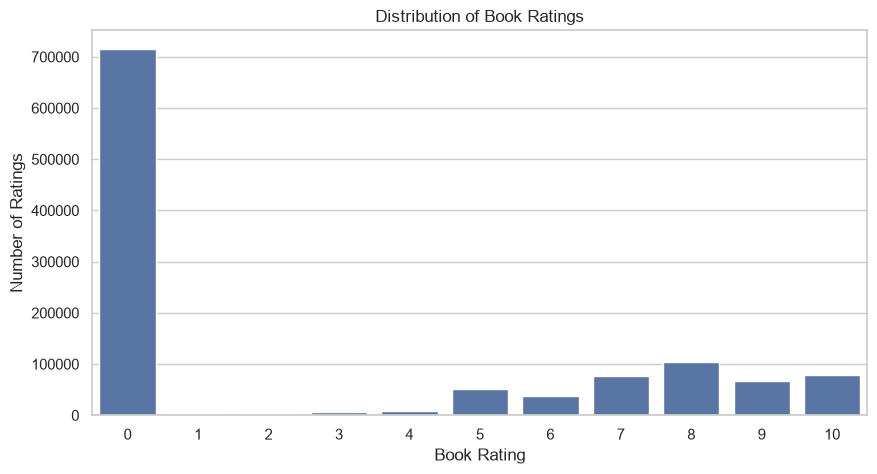

In [80]:
rating_counts = ratings['Book-Rating'].value_counts().sort_index()
display(rating_counts.to_frame('Count'))

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Distribution of Book Ratings')
plt.xlabel('Book Rating')
plt.ylabel('Number of Ratings')
plt.show()

## Explicit vs implicit ratings
We separate rating 0 from ratings greater than 0. This helps us understand how much of the ratings dataset contains actual user scores.



,Count
Rating = 0,716109
Rating > 0,433671


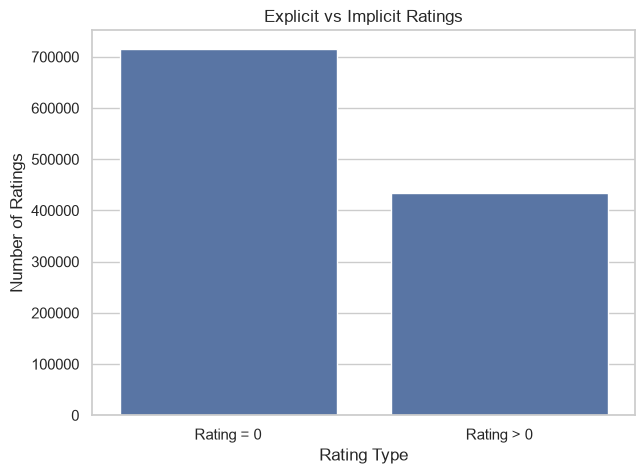

In [81]:
zero_ratings = (ratings['Book-Rating'] == 0).sum()
explicit_ratings = (ratings['Book-Rating'] > 0).sum()

rating_type = pd.Series(
    [zero_ratings, explicit_ratings],
    index=['Rating = 0', 'Rating > 0']
)

display(rating_type.to_frame('Count'))

plt.figure(figsize=(7, 5))
sns.barplot(x=rating_type.index, y=rating_type.values)
plt.title('Explicit vs Implicit Ratings')
plt.xlabel('Rating Type')
plt.ylabel('Number of Ratings')
plt.show()

## Age distribution of users
The Users dataset contains an Age column. We first remove missing and clearly invalid ages for visualization. The original users dataframe is not modified.



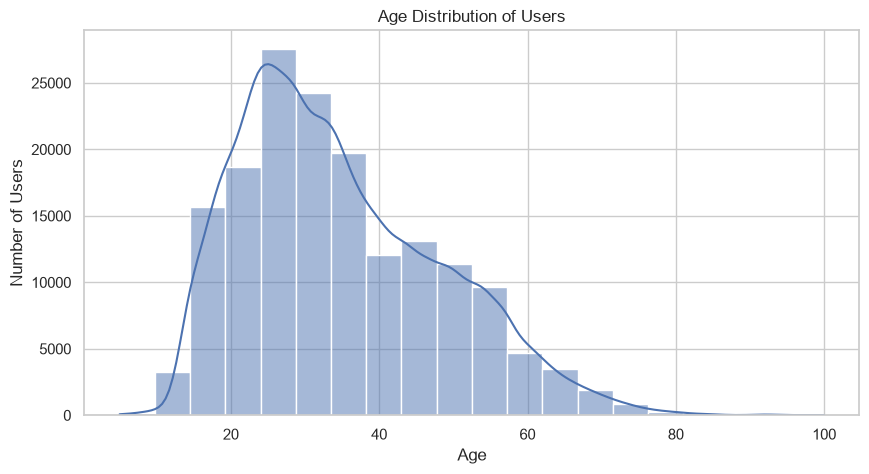

In [82]:
valid_age = users.loc[users['Age'].between(5, 100, inclusive='both'), 'Age'].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(valid_age, bins=20, kde=True)
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

## Most active users
Counting ratings per user helps us identify users who have provided a large number of ratings. This is useful because the original notebook later filters users who have given more than 200 ratings for collaborative filtering.



Top 10 most active users:


,Number of Ratings
User-ID,
11676,13602
198711,7550
153662,6109
98391,5891
35859,5850
212898,4785
278418,4533
76352,3367
110973,3100


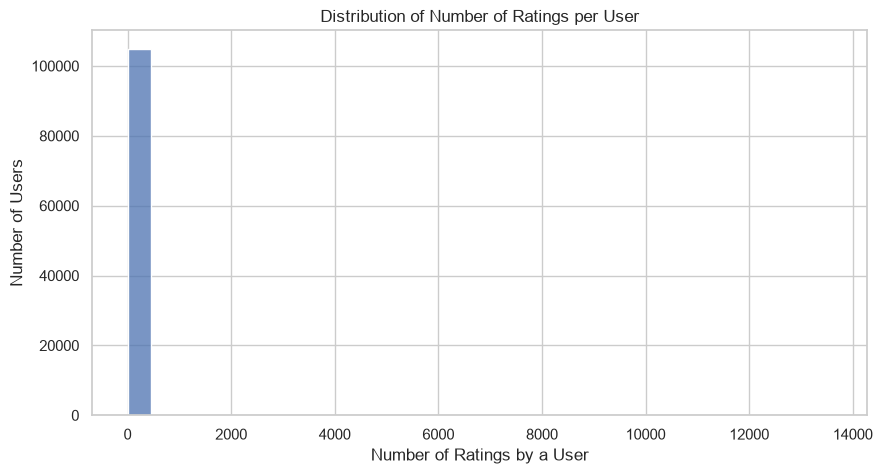

In [83]:
user_rating_count = ratings.groupby('User-ID')['Book-Rating'].count().sort_values(ascending=False)
print('Top 10 most active users:')
display(user_rating_count.head(10).to_frame('Number of Ratings'))

plt.figure(figsize=(10, 5))
sns.histplot(user_rating_count, bins=30)
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings by a User')
plt.ylabel('Number of Users')
plt.show()

## Most rated books
We count how many ratings each ISBN receives. This gives an initial view of book popularity before the notebook creates the popularity-based recommender.



In [84]:
book_rating_count = ratings.groupby('ISBN')['Book-Rating'].count().sort_values(ascending=False).head(10)
display(book_rating_count.to_frame('Number of Ratings'))

,Number of Ratings
ISBN,
0971880107,2502
0316666343,1295
0385504209,883
0060928336,732
0312195516,723
044023722X,647
0679781587,639
0142001740,615
067976402X,614


## Most common book authors
The Books dataset contains author information. We count the most frequent authors to understand which authors occur most often in the dataset.



,Number of Books
Book-Author,
Agatha Christie,632
William Shakespeare,567
Stephen King,524
Ann M. Martin,423
Carolyn Keene,373
Francine Pascal,372
Isaac Asimov,330
Nora Roberts,315
Barbara Cartland,307


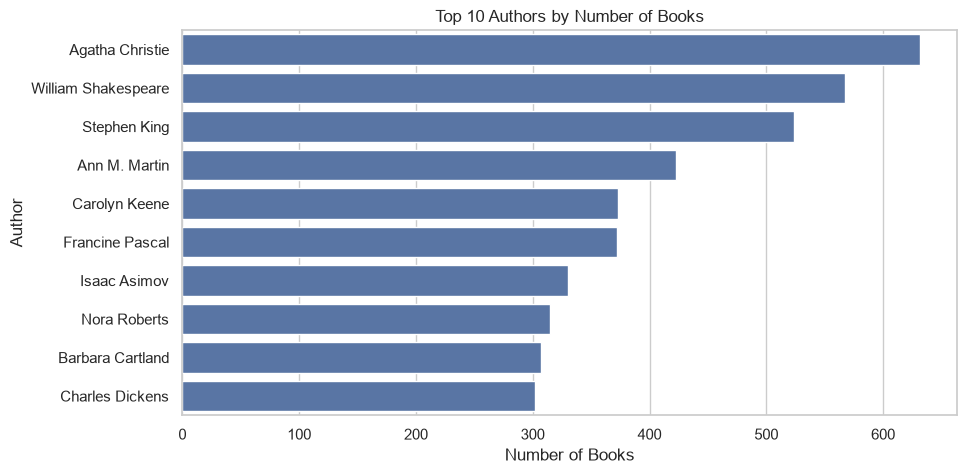

In [85]:
top_authors = books['Book-Author'].value_counts().head(10)
display(top_authors.to_frame('Number of Books'))

plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()

## Graph — Top 10 most-rated books
This horizontal bar graph shows the 10 books/ISBNs that received the highest number of ratings. It helps us visually identify highly interacted-with books.



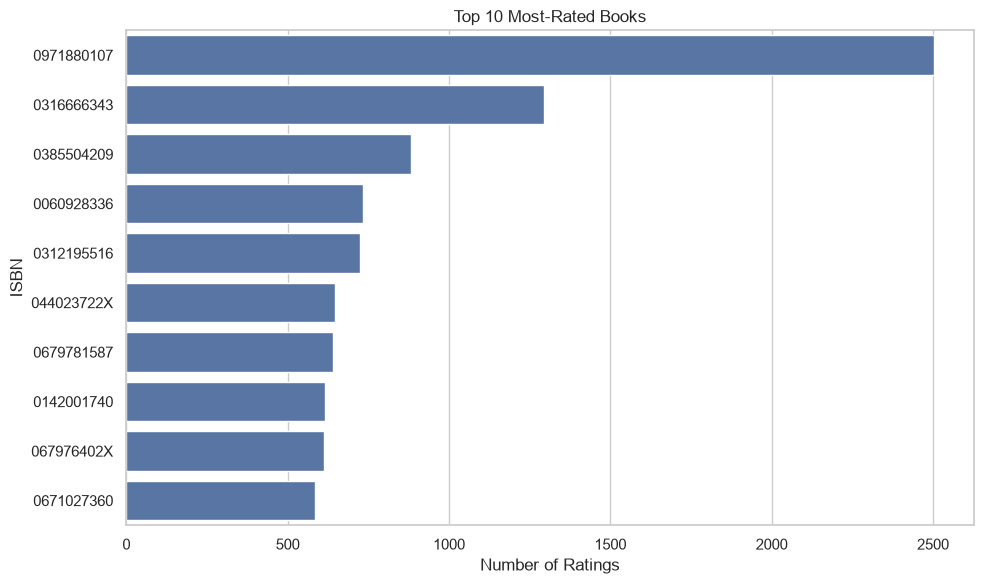

In [86]:
top_books = ratings['ISBN'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_books.values, y=top_books.index)
plt.title('Top 10 Most-Rated Books')
plt.xlabel('Number of Ratings')
plt.ylabel('ISBN')
plt.tight_layout()
plt.show()

## Graph — Distribution of ratings per user
This graph shows how the number of ratings is distributed across users. A long-tailed distribution indicates that a small group of users may contribute many ratings.



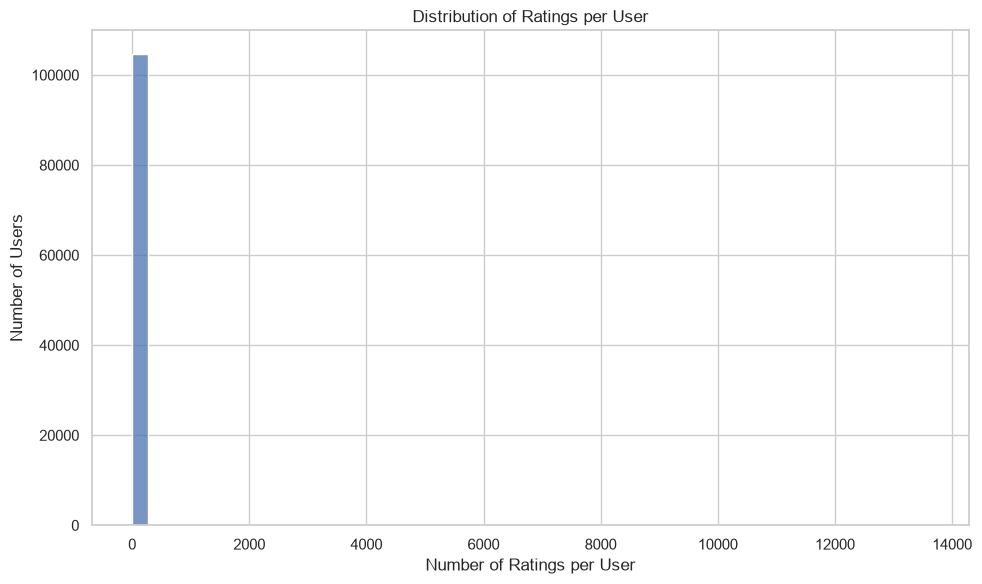

In [87]:
user_rating_counts = ratings.groupby('User-ID').size()

plt.figure(figsize=(10, 6))
sns.histplot(user_rating_counts, bins=50)
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

## Graph — Rating distribution excluding zero ratings
Because rating 0 is an implicit/non-rating entry, this graph focuses only on explicit ratings from 1 to 10. It makes the actual user-rating behavior easier to interpret.



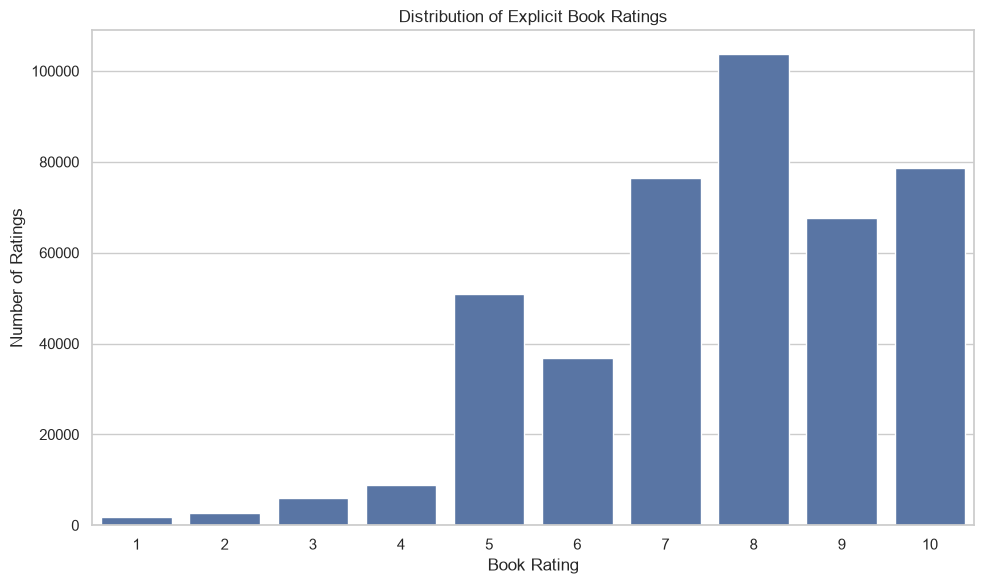

In [88]:
explicit_rating_counts = ratings.loc[ratings['Book-Rating'] > 0, 'Book-Rating'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=explicit_rating_counts.index, y=explicit_rating_counts.values)
plt.title('Distribution of Explicit Book Ratings')
plt.xlabel('Book Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

## Graph — Top 10 authors by number of books
This graph displays the authors with the largest number of books in the Books dataset.



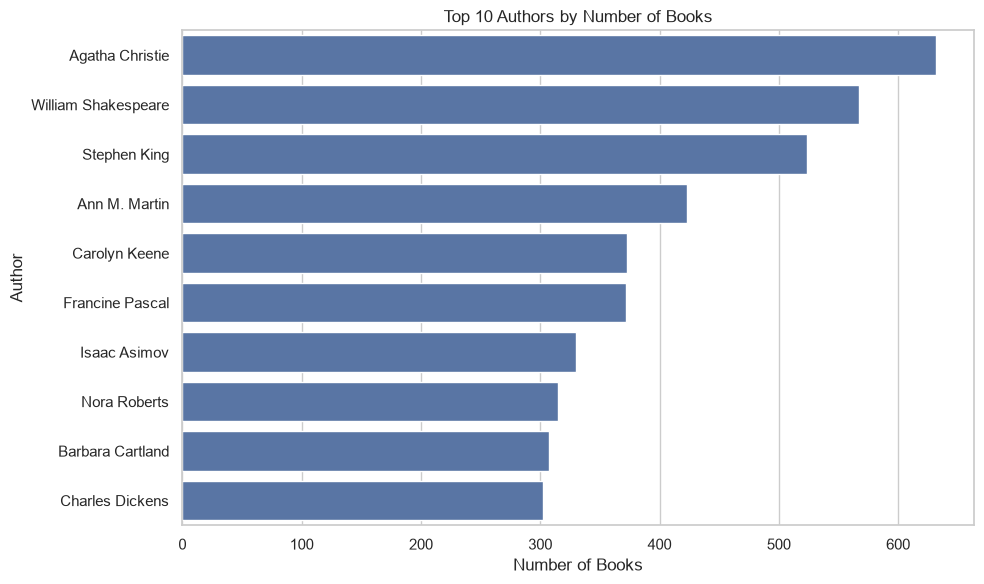

In [89]:
top_authors_graph = books['Book-Author'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_authors_graph.values, y=top_authors_graph.index)
plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

## Popularity Based Recommender System


In [90]:
ratings_with_name = ratings.merge(books,on='ISBN')


In [91]:
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Ã?lpiraten.,2
241067,Ã?Ã?rger mit Produkt X. Roman.,4
241068,Ã?Ã?sterlich leben.,1
241069,Ã?Ã?stlich der Berge.,3


In [92]:
avg_rating_df = ratings_with_name.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_rating_df.rename(columns={'Book-Rating':'avg_rating'},inplace=True)
avg_rating_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Ã?lpiraten.,0.000000
241067,Ã?Ã?rger mit Produkt X. Roman.,5.250000
241068,Ã?Ã?sterlich leben.,7.000000
241069,Ã?Ã?stlich der Berge.,2.666667


In [93]:
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df


,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Ã?lpiraten.,2,0.000000
241067,Ã?Ã?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Ã?sterlich leben.,1,7.000000
241069,Ã?Ã?stlich der Berge.,3,2.666667


In [94]:
popular_df = popular_df[popular_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50)

In [95]:
popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

In [96]:
popular_df['Image-URL-M'][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

## Collaborative Filtering Based Recommender System

In [97]:
x = ratings_with_name.groupby('User-ID').count()['Book-Rating'] > 200
educated_users = x[x].index


In [98]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(educated_users)]

In [99]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books = y[y].index

In [100]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]


In [101]:

pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [102]:
pt.fillna(0,inplace=True)

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [104]:
from sklearn.metrics.pairwise import cosine_similarity


In [105]:
similarity_scores = cosine_similarity(pt)

In [106]:
similarity_scores.shape


(706, 706)

In [107]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:5]
    
    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == pt.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
        
        data.append(item)
    
    return data

In [108]:
recommend('1984')

[['Animal Farm',
  'George Orwell',
  'http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg'],
 ["The Handmaid's Tale",
  'Margaret Atwood',
  'http://images.amazon.com/images/P/0449212602.01.MZZZZZZZ.jpg'],
 ['Brave New World',
  'Aldous Huxley',
  'http://images.amazon.com/images/P/0060809833.01.MZZZZZZZ.jpg'],
 ['The Vampire Lestat (Vampire Chronicles, Book II)',
  'ANNE RICE',
  'http://images.amazon.com/images/P/0345313860.01.MZZZZZZZ.jpg']]

In [109]:
pt.index[545]

"The Handmaid's Tale"

In [110]:
import pickle
pickle.dump(popular_df,open('popular.pkl','wb'))

In [111]:
books.drop_duplicates('Book-Title')


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271354,0449906736,Flashpoints: Promise and Peril in a New World,Robin Wright,1993,Ballantine Books,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [112]:
pickle.dump(pt,open('pt.pkl','wb'))
pickle.dump(books,open('books.pkl','wb'))
pickle.dump(similarity_scores,open('similarity_scores.pkl','wb'))
